# Imports

In [1]:
# =========================
# Numerical & Signal Processing Libraries
# =========================

import numpy as np              # Core numerical computing (arrays, math operations)
import scipy                    # Scientific computing ecosystem (base package)
import scipy.io                 # I/O utilities (e.g., loading/saving .mat files)
import scipy.signal             # Signal processing utilities (filters, FFTs, PSDs)
import matplotlib.pyplot as plt # Plotting and visualization

from scipy.signal import welch  # Welch’s method for Power Spectral Density estimation


# =========================
# Operating System Configuration
# =========================

import os

# Explicitly define the target PYNQ board.
# This is critical for RFSoC platforms so that
# PYNQ loads the correct hardware definitions and drivers.
os.environ['BOARD'] = 'RFSoC4x2'


# =========================
# PYNQ Framework Imports
# =========================

import pynq                     # Core PYNQ framework

from pynq import allocate       # Memory allocation for DMA-compatible buffers
from pynq import Overlay        # Used to load FPGA bitstreams (.bit + .hwh)


# =========================
# RFSoC-Specific Clocking & RF Data Converter Control
# =========================

import xrfclk                   # Manages RFSoC clock configuration (PL/PS clocks)
import xrfdc                    # Python interface to RF Data Converter (ADC/DAC tiles)


# =========================
# Utility Imports
# =========================

from time import sleep          # Simple delay utility (e.g., hardware settling time)

# Design Configuration

In [2]:
# =========================
# RF System Configuration Parameters
# =========================

# ADC/DAC sampling rate in MHz.
# 4915.2 MHz is a standard RFSoC clock rate, derived from the onboard PLL,
# and serves as the master sampling frequency for the RF Data Converters.
SAMPLING_RATE = 4915.2  # MHz


# =========================
# Digital Up/Down Conversion Parameters
# =========================

# Interpolation factor for the DAC path.
# Increases the effective output sample rate by this factor,
# enabling finer time resolution in waveform generation.
INTERPOLATION_FACTOR = 16

# Decimation factor for the ADC path.
# Reduces the incoming sample rate by this factor,
# easing downstream baseband processing load.
DECIMATION_FACTOR = 16


# =========================
# RF Frequency Planning
# =========================

# Carrier (center) frequency in MHz.
# This defines the RF mixing frequency used by the DUC/DDC blocks
# inside the RF Data Converter tiles.
CARRIER_FREQUENCY = 300  # MHz


# =========================
# Nyquist Zone Selection
# =========================

# Nyquist zone used for RF sampling.
# Zone 1 corresponds to direct sampling in the first Nyquist band
# (0 to Fs/2). Higher zones would imply intentional spectral folding.
NYQUIST_ZONE = 1

# Design Initialization

In [3]:
# =========================
# FPGA Design Initialization
# =========================

# Load the compiled FPGA design (bitstream + hardware handoff file).
# This programs the PL (Programmable Logic) and exposes IP cores
# as Python-accessible objects through the PYNQ overlay framework.
base = Overlay('design_1.bit')


# =========================
# RF Data Converter IP Handle
# =========================

# Obtain a handle to the RF Data Converter (RFDC) IP core instantiated
# in the FPGA design. This object provides software control over
# ADC/DAC tiles, mixers, interpolation/decimation, and calibration.
rfdc = base.usp_rf_data_converter_0


# Clock Configuration

In [4]:
# =========================
# RFSoC Clock Initialization
# =========================

def init_rf_clks(lmk_freq=245.76, lmx_freq=491.52):
    """
    Configure the RFSoC reference clocks.

    Parameters
    ----------
    lmk_freq : float
        Reference frequency (in MHz) for the LMK clock generator.
        Typically used as the system reference for the RF Data Converters.
    
    lmx_freq : float
        Reference frequency (in MHz) for the LMX clock synthesizer.
        Often used for high-speed RF PLL generation.
    """

    # Program the LMK and LMX clock chips on the RFSoC board.
    # This step is mandatory before enabling ADC/DAC tiles
    # to ensure deterministic sampling and mixer behavior.
    xrfclk.set_ref_clks(lmk_freq=lmk_freq, lmx_freq=lmx_freq)


# Initialize RF clocks using default, design-qualified frequencies.
# These values must be coherent with the Vivado clocking configuration.
init_rf_clks()


## DAC Configuration

In [5]:
# =========================
# DAC Tile Configuration and Startup
# =========================

# Select DAC tile 0 from the RF Data Converter IP.
# Each tile contains one or more DAC blocks sharing common clocking.
dac_tile = rfdc.dac_tiles[0]


# -------------------------
# DAC Tile Clock Configuration
# -------------------------

# Dynamically configure the DAC tile PLL.
# Arguments:
#   1        -> Enable PLL
#   491.52   -> Reference clock frequency in MHz (LMX output)
#   4915.2   -> Desired DAC sampling rate in MHz
#
# This step aligns the DAC tile clocking with the system-level
# sampling rate defined earlier.
dac_tile.DynamicPLLConfig(1, 491.52, 4915.2)


# -------------------------
# DAC Block Configuration
# -------------------------

# Select DAC block 0 within the tile.
# This is the actual signal generation path.
dac_block = dac_tile.blocks[0]

# Set the Nyquist zone for the DAC.
# Determines how the output spectrum is mapped relative
# to the sampling frequency.
dac_block.NyquistZone = NYQUIST_ZONE

# Configure the digital mixer frequency (in MHz).
# This sets the RF carrier for digital upconversion.
dac_block.MixerSettings['Freq'] = CARRIER_FREQUENCY

# Apply the mixer configuration.
# RFDC settings are staged and only take effect
# after issuing an explicit update event.
dac_block.UpdateEvent(xrfdc.EVENT_MIXER)


# -------------------------
# FIFO Enable and Tile Startup
# -------------------------

# Enable the DAC FIFO to buffer data between the PL
# and the high-speed DAC interface.
dac_tile.SetupFIFO(True)

# Start the DAC tile.
# This powers up the tile and makes the DAC operational.
dac_tile.StartUp()


## ADC Configuration

In [6]:
# =========================
# ADC Tile Configuration and Startup
# =========================

# Select ADC tile 2 from the RF Data Converter IP.
# Tile selection is design-specific and depends on
# how the RF ports are mapped in Vivado.
adc_tile = rfdc.adc_tiles[2]


# -------------------------
# ADC Tile Clock Configuration
# -------------------------

# Dynamically configure the ADC tile PLL.
# Arguments:
#   1        -> Enable PLL
#   491.52   -> Reference clock frequency in MHz
#   4915.2   -> Desired ADC sampling rate in MHz
#
# This ensures clock coherency between ADC and DAC paths.
adc_tile.DynamicPLLConfig(1, 491.52, 4915.2)


# -------------------------
# ADC Block Configuration
# -------------------------

# Select ADC block 0 within the tile.
# This block performs RF sampling and digital downconversion.
adc_block = adc_tile.blocks[0]

# Set the Nyquist zone for the ADC.
# Controls how the sampled RF spectrum is interpreted
# relative to the ADC sampling rate.
adc_block.NyquistZone = NYQUIST_ZONE

# Configure the digital mixer frequency (in MHz).
# The negative sign shifts the RF signal *down* to baseband,
# complementing the DAC upconversion frequency.
adc_block.MixerSettings['Freq'] = -1 * CARRIER_FREQUENCY

# Apply the mixer configuration.
# Mixer settings take effect only after issuing
# an explicit update event.
adc_block.UpdateEvent(xrfdc.EVENT_MIXER)


# -------------------------
# FIFO Enable and Tile Startup
# -------------------------

# Enable the ADC FIFO to buffer high-speed sample data
# before transferring it to the programmable logic or PS.
adc_tile.SetupFIFO(True)

# Start the ADC tile.
# This activates the ADC and begins data capture capability.
adc_tile.StartUp()


## Sine Wave Generation

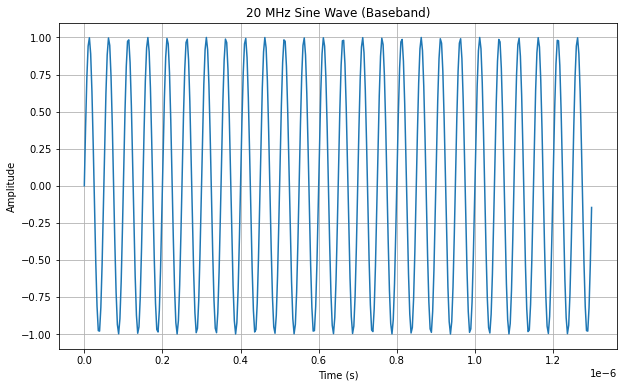

In [7]:
# =========================
# Baseband Test Signal Generation
# =========================

# Baseband tone frequency (Hz).
# This is the signal that will be digitally upconverted
# by the DAC mixer to the RF carrier.
f = 20e6  # 20 MHz


# Effective baseband sampling frequency after DAC interpolation.
# Although the RF DAC runs at multi-GHz rates, the user-visible
# sample rate is reduced by the interpolation factor.
fs = (SAMPLING_RATE * 1e6) / INTERPOLATION_FACTOR


# Signal duration.
# Defined as 2^16 periods of the sine wave to ensure:
#   - Integer number of cycles
#   - Good spectral purity
#   - Compatibility with power-of-two buffer sizes
duration = (1 / f) * (2 ** 16)


# Time axis for waveform generation.
# Creates uniformly spaced samples at the effective baseband rate.
t = np.arange(0, duration, 1 / fs)


# Generate a real-valued sinusoidal waveform.
# This represents a single-tone baseband signal.
sine_wave = np.sin(2 * np.pi * f * t)


# =========================
# Time-Domain Visualization
# =========================

# Create a figure for waveform inspection.
plt.figure(figsize=(10, 6))

# Plot only the first 400 samples to clearly visualize
# the waveform without excessive clutter.
plt.plot(t[:400], sine_wave[:400])

# Annotate the plot for clarity and reporting.
plt.title("20 MHz Sine Wave (Baseband)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# Display and then explicitly close the figure
# to free resources in long-running notebooks.
plt.show()
plt.close()


# Transmitter

In [8]:
# =========================
# Transmit Signal Preparation
# =========================

# Assign the generated waveform to the transmit signal.
# This abstraction allows easy swapping of test signals later.
tx_signal = sine_wave


# -------------------------
# I/Q Component Extraction
# -------------------------

# Extract real (I) and imaginary (Q) components.
# For a real-valued signal, the imaginary part will be zero,
# but this structure supports complex baseband signals as well.
tx_signal_real = np.real(tx_signal)
tx_signal_imag = np.imag(tx_signal)


# -------------------------
# I/Q Interleaving
# -------------------------

# Create an interleaved I/Q array:
# [I0, Q0, I1, Q1, I2, Q2, ...]
# This is the expected data format for the RFSoC DAC DMA path.
tx_signal_interleaved = np.zeros(2 * len(tx_signal))

tx_signal_interleaved[0::2] = tx_signal_real  # Even indices: I samples
tx_signal_interleaved[1::2] = tx_signal_imag  # Odd indices:  Q samples


# -------------------------
# Amplitude Scaling
# -------------------------

# Normalize and scale the signal to match the DAC input range.
# 16384 corresponds to a conservative full-scale value
# for a signed 16-bit DAC input, leaving headroom to avoid clipping.
tx_signal_scaled = 16384 * (
    tx_signal_interleaved / np.max(np.abs(tx_signal_interleaved))
)


# =========================
# DMA Buffer Allocation and Data Transfer
# =========================

# Total number of samples to be transferred to the DAC.
tx_transfer_size = len(tx_signal_scaled)


# Allocate physically contiguous DDR memory for DMA.
# The buffer must be int16 to match the DAC data interface.
input_buffer = allocate(
    shape=(tx_transfer_size,),
    dtype=np.int16
)


# Copy scaled waveform data into the DMA buffer.
# This explicit loop guarantees correct type casting
# and avoids silent truncation issues.
for i in range(tx_transfer_size):
    input_buffer[i] = tx_signal_scaled[i]


# -------------------------
# Start DMA Transmission
# -------------------------

# Initiate DMA transfer to the DAC.
# cyclic=True enables continuous waveform playback
# without CPU intervention (ideal for steady-state testing).
base.axi_dma_0.sendchannel.transfer(input_buffer, cyclic=True)


# Receiver

In [9]:
# =========================
# Receive Buffer Allocation
# =========================

# Define the receive transfer size.
# Matching the RX buffer size to the TX buffer size ensures:
#   - Time-aligned capture
#   - Simplified loopback analysis
#   - Consistent DMA transaction lengths
rx_transfer_size = len(tx_signal_scaled)


# -------------------------
# RX DMA Buffers (I/Q)
# -------------------------

# Allocate DDR buffers for the received real (I) samples.
# int16 matches the ADC output data format.
output_buffer_real = pynq.allocate(
    shape=(rx_transfer_size,),
    dtype=np.int16
)

# Allocate DDR buffers for the received imaginary (Q) samples.
# Separate buffers simplify post-processing and visualization.
output_buffer_imag = pynq.allocate(
    shape=(rx_transfer_size,),
    dtype=np.int16
)


In [10]:
# =========================
# RX DMA Capture and Control
# =========================

# Arm DMA channel for receiving real (I) samples from the ADC path.
# Data will be written directly into the allocated DDR buffer.
base.axi_dma_1.recvchannel.transfer(output_buffer_real)

# Arm DMA channel for receiving imaginary (Q) samples from the ADC path.
# This assumes the design separates I and Q streams at the PL level.
base.axi_dma_2.recvchannel.transfer(output_buffer_imag)


# -------------------------
# Packet Generator Control
# -------------------------

# Configure the packet generator with the number of samples to capture.
# Offset 0x00 typically corresponds to the packet length register.
base.packet_generator_0.write(0x00, rx_transfer_size)

# Start packet generation.
# Writing '1' to the control register triggers the capture process.
base.packet_generator_0.write(0x04, int(1))


# -------------------------
# DMA Synchronization
# -------------------------

# Block execution until the real (I) DMA transfer is complete.
# Ensures the full buffer has been received before proceeding.
base.axi_dma_1.recvchannel.wait()

# Block execution until the imaginary (Q) DMA transfer is complete.
base.axi_dma_2.recvchannel.wait()


# -------------------------
# Packet Generator Shutdown
# -------------------------

# Stop packet generation.
# This cleanly terminates the capture operation and prevents
# unintended additional data from being streamed.
base.packet_generator_0.write(0x04, int(0))


In [11]:
# =========================
# RX Signal Reconstruction (Time Domain)
# =========================

# Reconstruct the complex baseband RX signal from separate
# real (I) and imaginary (Q) DMA buffers.
# This forms the complex-valued time-domain signal.
rx_signal_t = np.array(output_buffer_real) + 1j * np.array(output_buffer_imag)


# =========================
# Frequency-Domain Analysis
# =========================

# Compute the FFT of the received signal.
# fftshift is applied to center the DC component,
# resulting in a symmetric frequency spectrum.
rx_signal_f = np.fft.fftshift(np.fft.fft(rx_signal_t))


# Number of FFT points (equal to the capture length).
N = len(rx_signal_f)


# Generate the frequency axis corresponding to the FFT bins.
#   - d = 1/fs specifies the sample spacing in seconds
#   - fftshift aligns the frequency vector with the shifted FFT
#   - Division by 1e6 converts Hz to MHz for RF-friendly plotting
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1 / fs)) / 1e6


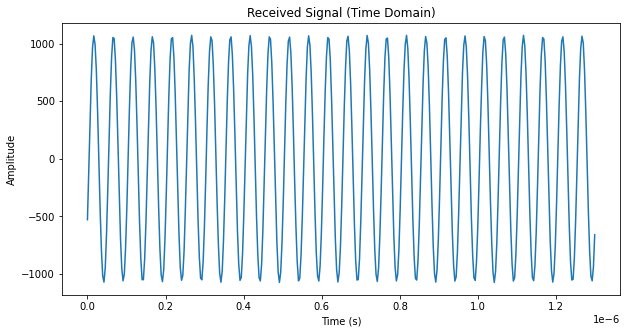

In [12]:
# =========================
# Time-Domain RX Signal Visualization
# =========================

# Compute the total duration of the received signal.
# Duration = number of samples × sampling period.
duration = len(rx_signal_t) * (1 / fs)


# Generate the time axis for the received signal.
# This aligns each sample with its corresponding time instant.
rx_t = np.arange(0, duration, 1 / fs)


# -------------------------
# Plot Time-Domain Waveform
# -------------------------

# Create a figure for RX signal inspection.
plt.figure(figsize=(10, 5))

# Plot only the first 400 samples of the real (I) component.
# This avoids clutter and makes waveform integrity easy to assess.
plt.plot(rx_t[:400], rx_signal_t.real[:400])

# Annotate the plot for clarity and reporting.
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Received Signal (Time Domain)')

# Render and clean up the figure.
plt.show()
plt.close()


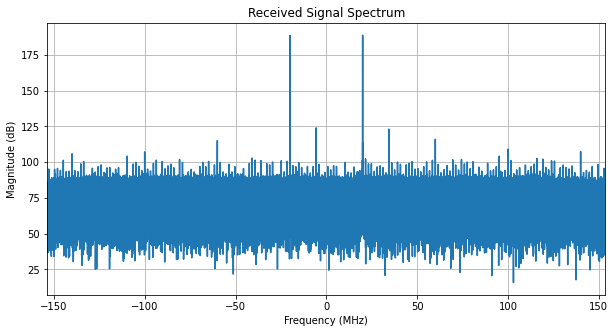

In [13]:
# =========================
# Frequency-Domain Visualization (Magnitude Spectrum)
# =========================

# Convert the complex FFT result to magnitude in decibels (dB).
# 20*log10(|X(f)|) is used for amplitude spectra.
rx_signal_f_dB = 20 * np.log10(np.abs(rx_signal_f))


# -------------------------
# Plot Frequency Spectrum
# -------------------------

# Create a figure for spectral inspection.
plt.figure(figsize=(10, 5))

# Plot the magnitude spectrum versus frequency.
# The spectrum is already DC-centered due to fftshift.
plt.plot(freqs, rx_signal_f_dB)

# Annotate the plot for clarity and technical reporting.
plt.title("Received Signal Spectrum")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)


# Limit the x-axis to the effective baseband bandwidth.
# fs/2 defines the Nyquist limit of the sampled signal.
plt.xlim(-fs / 2e6, fs / 2e6)

# Render the figure.
plt.show()


In [14]:
# =========================
# Programmatic Frequency Check
# =========================

# Find the index of the peak magnitude in the FFT spectrum.
# This corresponds to the dominant frequency component (the transmitted sine wave).
peak_index = np.argmax(rx_signal_f_dB)

# Retrieve the corresponding frequency in MHz.
received_frequency = freqs[peak_index]

# Print the result.
# This provides a simple verification that the transmitted tone
# appears at the expected frequency after the full RFSoC chain.
print("Received Sine Wave Frequency =", received_frequency, "MHz")


Received Sine Wave Frequency = 19.999999205271433 MHz


# Shutdown

In [15]:
# =========================
# Hardware Cleanup and Shutdown
# =========================

# Stop the TX DMA channel to halt waveform transmission.
# This prevents further writes to the DAC and frees the channel for future use.
base.axi_dma_0.sendchannel.stop()


# Shut down the DAC tile.
# Powers down the DAC blocks and disables the FIFO.
# Ensures that the DAC is in a safe state and prevents unwanted output.
dac_tile.ShutDown()


# Shut down the ADC tile.
# Powers down the ADC blocks and disables the FIFO.
# Ensures no further sampling occurs and frees resources for subsequent experiments.
adc_tile.ShutDown()
